In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/checksums.md5
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndbufes_TaskIII_parsed_test.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndb-ufes.xlsx
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndb-ufes.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/ndbufes_TaskII_parsed_test.csv
/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("--- Starting Phase 1: Data Loading ---")
BASE_PATH = '/kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/' 

# FIX 1: Point exactly to the subfolder where the images live
IMAGE_DIR = os.path.join(BASE_PATH, 'patch', 'images-patches')
CSV_PATH = os.path.join(BASE_PATH, 'ndb-ufes.csv')

df = pd.read_csv(CSV_PATH)
print(f"Total initial records: {len(df)}")

2026-05-11 19:34:31.850337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778528072.256644      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778528072.387217      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778528073.402740      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778528073.402788      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778528073.402791      23 computation_placer.cc:177] computation placer alr

--- Starting Phase 1: Data Loading ---
Total initial records: 237


In [3]:
print(df.columns.tolist())

['public_id', 'lesion_id', 'patient_id', 'path', 'localization', 'larger_size', 'tobacco_use', 'alcohol_consumption', 'sun_exposure', 'gender', 'skin_color', 'age_group', 'diagnosis', 'dysplasia_severity', 'TaskII', 'TaskIII', 'TaskIV']


In [4]:
# ==========================================
# PHASE 2 & 3: BULLETPROOF PREPROCESSING
# ==========================================
print("\n--- Starting Phase 2: Feature Engineering & Auto-Pathing ---")

# 1. Map the 'diagnosis' column to High vs Low Risk
def map_risk(diagnosis_value):
    d = str(diagnosis_value).lower()
    if 'carcinoma' in d or 'with dysplasia' in d:
        return 'high_risk'
    else:
        return 'low_risk'

df['risk_label'] = df['diagnosis'].apply(map_risk)

# 2. Hunt down the exact folder containing the images
print("Hunting for the actual image folder...")
actual_img_dir = None
for root, dirs, files in os.walk(BASE_PATH):
    # Check if a known image from the CSV exists in this folder
    if '0000.png' in files: 
        actual_img_dir = root
        break

if actual_img_dir:
    print(f"SUCCESS! Images found at: {actual_img_dir}")
else:
    print("CRITICAL ERROR: Could not find the image files. Check if they were uploaded correctly.")

# 3. Create absolute paths for every image so Keras cannot possibly miss them
df['absolute_path'] = df['path'].apply(lambda x: os.path.join(actual_img_dir, str(x)))

# Verify the very first file actually exists on the hard drive
test_path = df['absolute_path'].iloc[0]
print(f"Testing first file path: {test_path}")
print(f"Does file exist? {os.path.exists(test_path)}")

print("\n--- Starting Phase 3: Splitting & Generators ---")
# 4. Split the data
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['risk_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['risk_label'], random_state=42)

# 5. Set up Image Generators
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, vertical_flip=True)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# 6. Stream images (NOTICE: directory=None because we are using absolute paths now)
print("\nLoading Training Data...")
train_gen = train_datagen.flow_from_dataframe(
    train_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary'
)

print("Loading Validation Data...")
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)

print("Loading Testing Data...")
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, directory=None, x_col='absolute_path', y_col='risk_label',
    target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)


--- Starting Phase 2: Feature Engineering & Auto-Pathing ---
Hunting for the actual image folder...
SUCCESS! Images found at: /kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/images/images
Testing first file path: /kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/images/images/0000.png
Does file exist? True

--- Starting Phase 3: Splitting & Generators ---

Loading Training Data...
Found 189 validated image filenames belonging to 2 classes.
Loading Validation Data...
Found 24 validated image filenames belonging to 2 classes.
Loading Testing Data...
Found 24 validated image filenames belonging to 2 classes.


In [5]:
import os

print("--- DIAGNOSTIC CHECK ---")
# 1. Look inside the patch folder
try:
    files = os.listdir(IMAGE_DIR)
    print(f"Total items in folder: {len(files)}")
    print(f"First 10 items: {files[:10]}")
except Exception as e:
    print(f"Folder error: {e}")

# 2. Look at what the 'path' column contains
print("\nFirst 5 rows of the 'path' column:")
print(df['path'].head())

--- DIAGNOSTIC CHECK ---
Total items in folder: 1
First 10 items: ['patch']

First 5 rows of the 'path' column:
0    0000.png
1    0001.png
2    0002.png
3    0003.png
4    0004.png
Name: path, dtype: object


In [6]:
# ==========================================
# PHASE 4: MODEL BUILDING & TRAINING
# ==========================================
print("\n--- Starting Phase 4: Model Building (ResNet50) ---")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers to keep their pre-trained knowledge

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Prevents overfitting
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile using Recall to catch True Positives (crucial for cancer detection)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

print("Beginning Training (This will take a few minutes)...")
# Train the model! Watch the epochs output here.
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

# Save the model
model.save('/kaggle/working/oral_risk_classifier.h5')
print("\nModel saved successfully to /kaggle/working/oral_risk_classifier.h5!")


--- Starting Phase 4: Model Building (ResNet50) ---


I0000 00:00:1778528115.929515      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778528115.935787      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Beginning Training (This will take a few minutes)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778528135.843679      74 service.cc:152] XLA service 0x7dd99004e070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778528135.843721      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778528135.843725      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778528138.041380      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/12 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4688 - loss: 0.8761 - recall: 0.4909 

I0000 00:00:1778528143.273469      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.4865 - loss: 0.8757 - recall: 0.6055 - val_accuracy: 0.6250 - val_loss: 0.7779 - val_recall: 1.0000
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5233 - loss: 0.8239 - recall: 0.8325 - val_accuracy: 0.6250 - val_loss: 0.6614 - val_recall: 1.0000
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6243 - loss: 0.6998 - recall: 0.9392 - val_accuracy: 0.4167 - val_loss: 0.6871 - val_recall: 0.3333
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5421 - loss: 0.7078 - recall: 0.6368 - val_accuracy: 0.6250 - val_loss: 0.6716 - val_recall: 1.0000
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6045 - loss: 0.7028 - recall: 0.9255 - val_accuracy: 0.6250 - val_loss: 0.6583 - val_recall: 1.0000
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5759 - loss: 0.7047 - recall: 0.8588 - val_accuracy: 0.6250 - val_loss: 0.6586 - val_recall: 1.0000
Epoch 7/10
12/12 ━━━━━━━━━━


Model saved successfully to /kaggle/working/oral_risk_classifier.h5!



--- Starting Phase 5: Evaluation ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step

Classification Report:
              precision    recall  f1-score   support

   high_risk       0.00      0.00      0.00         9
    low_risk       0.62      1.00      0.77        15

    accuracy                           0.62        24
   macro avg       0.31      0.50      0.38        24
weighted avg       0.39      0.62      0.48        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


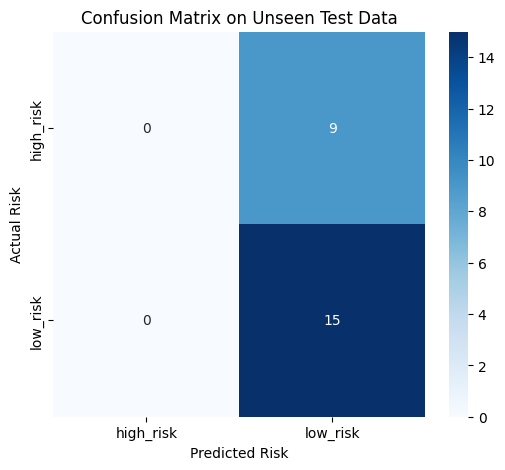

In [7]:
# ==========================================
# PHASE 5: EVALUATION ON UNSEEN DATA
# ==========================================
print("\n--- Starting Phase 5: Evaluation ---")
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Unseen Test Data')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()


--- Starting Phase 4: Advanced Model Building ---
Applying Class Weights to penalize missed cancer cases: {0: np.float64(1.3309859154929577), 1: np.float64(0.8008474576271186)}
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Beginning Fine-Tuning (This will take a bit longer)...
Epoch 1/15


2026-05-11 19:39:57.422338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:39:57.557286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:39:59.102248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:39:59.243553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 7:23 40s/step - accuracy: 0.6250 - loss: 0.6244 - recall: 0.3333

2026-05-11 19:40:19.042177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:40:19.176518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:40:20.705898: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:40:20.847527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5152 - loss: 0.6964 - recall: 0.3512

2026-05-11 19:40:59.177109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:40:59.310895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:41:00.823924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 19:41:00.965325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 93s 5s/step - accuracy: 0.5118 - loss: 0.6985 - recall: 0.3523 - val_accuracy: 0.3750 - val_loss: 0.7143 - val_recall: 0.0000e+00
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4521 - loss: 0.7093 - recall: 0.3982 - val_accuracy: 0.3750 - val_loss: 0.7052 - val_recall: 0.0000e+00
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4657 - loss: 0.7309 - recall: 0.4320 - val_accuracy: 0.3750 - val_loss: 0.6997 - val_recall: 0.0000e+00
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4993 - loss: 0.7069 - recall: 0.4571 - val_accuracy: 0.6250 - val_loss: 0.6907 - val_recall: 1.0000
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.4986 - loss: 0.7107 - recall: 0.5528 - val_accuracy: 0.3750 - val_loss: 0.7024 - val_recall: 0.0000e+00
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5108 - loss: 0.7277 - recall: 0.6209 - val_accuracy: 0.3750 - val_loss: 0.7189 - val_recall: 0.0000e+00
Epoch 7


Advanced Model saved to /kaggle/working/oral_risk_classifier_v2.h5

--- Starting Phase 5: Evaluation ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step

Classification Report:
              precision    recall  f1-score   support

   high_risk       0.38      1.00      0.55         9
    low_risk       0.00      0.00      0.00        15

    accuracy                           0.38        24
   macro avg       0.19      0.50      0.27        24
weighted avg       0.14      0.38      0.20        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


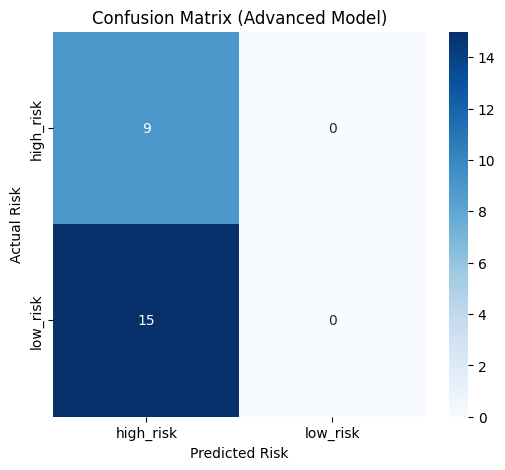

In [8]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetV2B0

# ==========================================
# PHASE 4: ADVANCED MODELING (EfficientNet + Fine-Tuning)
# ==========================================
print("\n--- Starting Phase 4: Advanced Model Building ---")

# 1. Automatically calculate Class Weights to fix the imbalance
train_labels = train_gen.classes
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(weights))
print(f"Applying Class Weights to penalize missed cancer cases: {class_weight_dict}")

# 2. Upgrade to EfficientNetV2
# EfficientNetV2 is often superior to ResNet for complex medical textures
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 3. FINE TUNING: Unfreeze the top layers
base_model.trainable = True
# Freeze all layers EXCEPT the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# 4. Compile with a lower learning rate (1e-4) so we don't destroy the pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("Beginning Fine-Tuning (This will take a bit longer)...")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=15, 
    class_weight=class_weight_dict # Injecting the penalty weights here!
)

model.save('/kaggle/working/oral_risk_classifier_v2.h5')
print("\nAdvanced Model saved to /kaggle/working/oral_risk_classifier_v2.h5")

# ==========================================
# PHASE 5: EVALUATION ON UNSEEN DATA
# ==========================================
print("\n--- Starting Phase 5: Evaluation ---")
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Advanced Model)')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()

In [9]:
# ==========================================
# PHASE 6: SINGLE IMAGE INFERENCE 
# ==========================================
print("\n--- Starting Phase 6: Inference Test ---")
def predict_single_image(image_path, model_path='/kaggle/working/oral_risk_classifier.h5'):
    # Load model
    loaded_model = tf.keras.models.load_model(model_path)
    
    # Load and preprocess image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    prediction_prob = loaded_model.predict(img_array, verbose=0)[0][0]
    
    # Interpret
    high_risk_idx = train_gen.class_indices['high_risk']
    if round(prediction_prob) == high_risk_idx:
        return f"HIGH RISK (Confidence: {prediction_prob:.4f})"
    else:
        return f"LOW RISK (Confidence: {(1.0 - prediction_prob):.4f})"

# Grab a random image from our test set using the absolute path we created
sample_image_path = test_df.iloc[0]['absolute_path']

print(f"Testing real-world inference on image: {sample_image_path}")
result = predict_single_image(sample_image_path)
print(f"\n>> Final Output: {result} <<")


--- Starting Phase 6: Inference Test ---
Testing real-world inference on image: /kaggle/input/datasets/sanhithreddy/ndb-ufes-oral-risk/NDB-UFES An oral cancer and leukoplakia dataset composed of histopathological images and patient data/images/images/0051.png



>> Final Output: LOW RISK (Confidence: 0.3732) <<
